
# Lab1_3: PDE

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#### **Exercise 1**: Lab1_3: finite-differences with tolerance **Jacobi method**


SOlve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
2. Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.


In [3]:
def Laplace2D(V_ini, x, y, tol=1e-3, max_iter=1000):

  Nmax = V_ini.shape[0]
  V = V_ini.copy()

  for _ in range(int(max_iter)):
    # Comparación con el valor anterior para evaluar convergencia de la solución
    V_prev = V.copy()
    
    # Iteración sobre el grid
    for i in range(1, Nmax - 1):
      for j in range(1, Nmax - 1):
        V[i, j] = 0.25 * (V[i + 1, j] + V[i - 1, j] + V[i, j + 1] + V[i, j - 1])

    # Tolerancia
    err = np.max(np.abs(V - V_prev))
    if err < tol:
      break

  X, Y = np.meshgrid(x, y)
  Z = V[X, Y]

  return X, Y, Z


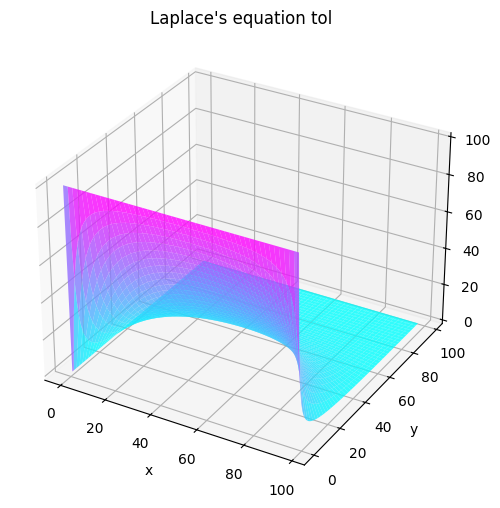

In [4]:
#Initial V matrix
Nmax = 100
tol = 1e-3

V_ini = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(0, Nmax):
  V_ini[k,0] = 100.0 # let line at 100V


x = np.arange(0, Nmax-1, 1)
y = x

# #Run Laplace2D rutine
X, Y, Z = Laplace2D(V_ini, x, y)

#Plot the field

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation tol')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()


En lugar de elegir el número de iteraciones como breakpoint de la solución, se elige una tolerancia `tol`, que es el nivel de cambio que acepto como la convergencia de la solución (ya no está cambiando de forma importante). El algoritmo va actualizando la malla usando el promedio de los vecinos (relajación) y, después de cada barrido completo, compara la solución nueva con la anterior. Si en toda la malla el cambio máximo es menor que `tol`, se considera que la solución ya convergió y se detiene. Para evitar quedarse corriendo para siempre si algo no converge, también se pone un `max_iter` como límite de seguridad.


N términos necesarios para tol=0.0001: 2


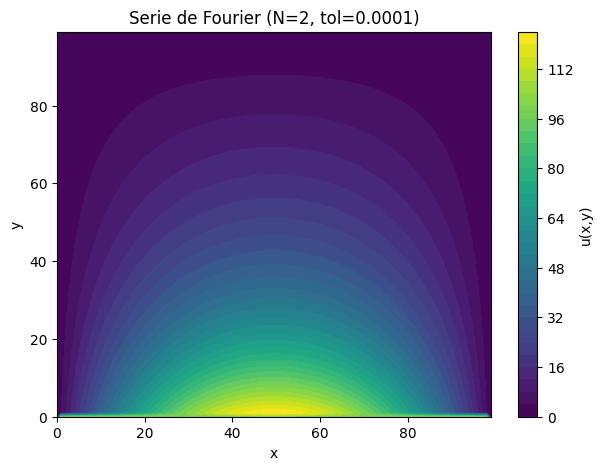

In [5]:
# Solución analítica por serie de Fourier

Nmax = 100
x = np.arange(Nmax)
y = np.arange(Nmax)
L = x[-1]  # dominio: 0 <= x <= L, con Δ=1

tol = 1e-4
n_max = 500

# Condición de frontera u(x,0)=V(x)=100V (y=0), con V(0)=V(L)=0 para compatibilidad con u(0,y)=u(L,y)=0
Vx = 100.0 * np.ones_like(x, dtype=float)
Vx[0] = 0.0
Vx[-1] = 0.0

X, Y = np.meshgrid(x, y)
Z_fourier = np.zeros((len(y), len(x)), dtype=float)
Z_prev = np.zeros_like(Z_fourier)

N_terms = 0
err = np.inf

for n in range(1, n_max + 1):
    # b_n = (2/L) ∫_0^L V(x) sin(nπx/L) dx
    bn = (2.0 / L) * np.trapezoid(Vx * np.sin(n * np.pi * x / L), x)

    term = (
        bn
        * (np.sinh(n * np.pi * (L - y) / L) / np.sinh(n * np.pi))[:, None]
        * np.sin(n * np.pi * x / L)[None, :]
    )
    Z_fourier = Z_fourier + term

    # imponer fronteras
    Z_fourier[0, :] = Vx
    Z_fourier[-1, :] = 0
    Z_fourier[:, 0] = 0
    Z_fourier[:, -1] = 0

    err = np.max(np.abs(Z_fourier - Z_prev))
    N_terms = n

    # Tolerancia
    if err < tol:
        break

    Z_prev = Z_fourier.copy()

print(f"N términos necesarios para tol={tol}: {N_terms}")

plt.figure(figsize=(7, 5))
plt.contourf(X, Y, Z_fourier, levels=30)
plt.colorbar(label="u(x,y)")
plt.title(f"Serie de Fourier (N={N_terms}, tol={tol})")
plt.xlabel("x")
plt.ylabel("y")
plt.show()



#### **Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

### Procedimiento numerico 

Para resolver $\nabla^2u=\frac{\partial^2u}{\partial x^2}+\frac{\partial^2u}{\partial y^2}=0$, en lugar de $y\in[0,\infty)$ se usa el dominio truncado $y\in[0,5L]$, tomando $u(x,5L)\approx 0$ como aproximacion de $u(x,\infty)=0$.

Con malla uniforme $\Delta x=\Delta y=\Delta=1$, para un punto interior $(i,j)$:
$\frac{u_{i+1,j}-2u_{i,j}+u_{i-1,j}}{\Delta^2}+\frac{u_{i,j+1}-2u_{i,j}+u_{i,j-1}}{\Delta^2}=0$,
por lo tanto
$u_{i,j}=\frac{1}{4}\left(u_{i+1,j}+u_{i-1,j}+u_{i,j+1}+u_{i,j-1}\right)$.

Se itera hasta convergencia con cierto nivel de tolerancia

Condiciones de borde usadas:
- $u(x,0)=u_0\sin(2\pi x/L)$
- $u(0,y)=0$
- $u(L,y)=0$
- $u(x,5L)=0$ (aproxima $u(x,\infty)=0$)

La solucion analitica esperada para este caso es $u(x,y)=u_0\sin(2\pi x/L)e^{-2\pi y/L}$.


Convergencia en 2359 iteraciones, err=9.993e-04


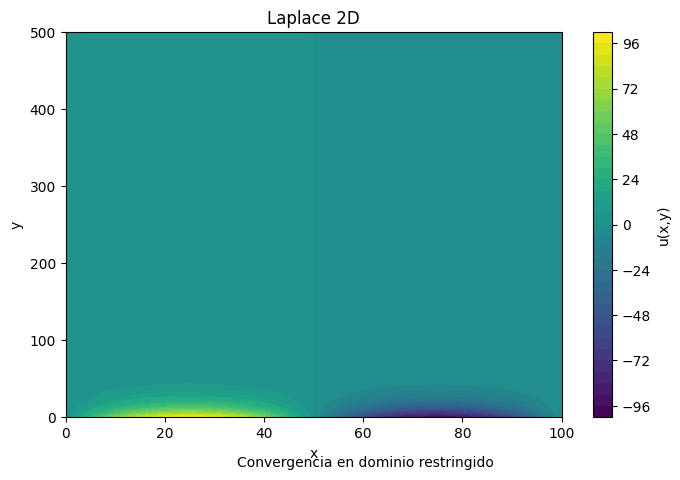

In [10]:

L = 100
u0 = 100.0
dx = dy = 1.0
tol = 1e-3
max_iter = 40000

Nx = int(L / dx) + 1
Ny = int(5 * L / dy) + 1

x = np.linspace(0, L, Nx)
y = np.linspace(0, 5 * L, Ny)
X, Y = np.meshgrid(x, y)

U = np.zeros((Ny, Nx), dtype=float)

# Bordes
U[0, :] = u0 * np.sin(2 * np.pi * x / L)    # y = 0
U[-1, :] = 0.0                              # y = 5L ~ infinito
U[:, 0] = 0.0                               # x = 0
U[:, -1] = 0.0                              # x = L

for k in range(max_iter):
    U_prev = U.copy()
    U[1:-1, 1:-1] = 0.25 * (
        U_prev[1:-1, 2:] + U_prev[1:-1, :-2] + U_prev[2:, 1:-1] + U_prev[:-2, 1:-1]
    )

    # Reaplicar bordes
    U[0, :] = u0 * np.sin(2 * np.pi * x / L)
    U[-1, :] = 0.0
    U[:, 0] = 0.0
    U[:, -1] = 0.0

    err = np.max(np.abs(U - U_prev))
    if err < tol:
        break

print(f"Convergencia en {k+1} iteraciones, err={err:.3e}")

plt.figure(figsize=(8, 5))
plt.contourf(X, Y, U, levels=35, cmap="viridis")
plt.colorbar(label="u(x,y)")
plt.title("Laplace 2D")
plt.figtext(0.5, 0.01, 'Convergencia en dominio restringido', ha='center')
plt.xlabel("x")
plt.ylabel("y")
plt.show()


Solución Analítica: Ecuación de Laplace en 2D

Para un dominio semi-infinito $0 \leq x \leq L$ y $y \geq 0$, resolvemos la ecuación de Laplace:

$$\frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2} = 0$$

<h3> 1. Condiciones de Contorno </h3>

1. $U(0, y) = 0$
2. $U(L, y) = 0$
3. $U(x, \infty) = 0$
4. $U(x, 0) = V$

<h3> 2. Separación de Variables </h3>


Proponemos una solución de la forma $U(x, y) = X(x)Y(y)$. Al sustituir en la ecuación original y dividir por $X(x)Y(y)$, obtenemos:

$$\frac{1}{X} \frac{d^2 X}{dx^2} = -\frac{1}{Y} \frac{d^2 Y}{dy^2} = -k^2$$

Esto genera dos ecuaciones diferenciales ordinarias (EDO):

1. $X''(x) + k^2 X(x) = 0$
2. $Y''(y) - k^2 Y(y) = 0$

<h3> 3. Solución para X </h3>


La solución general es 

$X(x) = A \sin(kx) + B \cos(kx)$.
- Aplicando $X(0) = 0 \implies B = 0$.
- Aplicando $X(L) = 0 \implies \sin(kL) = 0$, lo que nos da los autovalores:
$$k_n = \frac{n\pi}{L}, \quad n = 1, 2, 3, \dots$$

<h3> 4. Solución para Y </h3>


La solución general es $Y(y) = C e^{ky} + D e^{-ky}$.
- Dado que $U(x, \infty) = 0$, el término $e^{ky}$ debe anularse ($C = 0$) para evitar divergencia.
- Por lo tanto: $Y_n(y) = D_n e^{-\frac{n\pi y}{L}}$.

<h3> 5. Superposición y Coeficientes </h3>


La solución general es la suma de las soluciones particulares:
$$U(x, y) = \sum_{n=1}^{\infty} C_n \sin\left(\frac{n\pi x}{L}\right) e^{-\frac{n\pi y}{L}}$$

Aplicamos la última condición $U(x, 0) = V$:
$$V = \sum_{n=1}^{\infty} C_n \sin\left(\frac{n\pi x}{L}\right)$$

Usando la ortogonalidad de la función seno, el coeficiente $C_n$ es:
$$C_n = \frac{2}{L} \int_0^L V \sin\left(\frac{n\pi x}{L}\right) dx$$
$$C_n = \frac{2V}{L} \left[ -\frac{L}{n\pi} \cos\left(\frac{n\pi x}{L}\right) \right]_0^L = \frac{2V}{n\pi} (1 - (-1)^n)$$

- Si $n$ es par, $C_n = 0$.
- Si $n$ es impar, $C_n = \frac{4V}{n\pi}$.

<h3> 6. Solución Final </h3>


Definiendo $n = 2m - 1$:

$$U(x, y) = \frac{4V}{\pi} \sum_{m=1}^{\infty} \frac{1}{2m-1} \sin\left(\frac{(2m-1)\pi x}{L}\right) e^{-\frac{(2m-1)\pi y}{L}}$$